In [4]:
# importo las librerías necesarias

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [5]:
# cargo el dataset
farmacos = pd.read_csv("drugLibTrain_raw.csv", sep=",")
farmacos.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [6]:
farmacos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   urlDrugName        3107 non-null   str  
 1   rating             3107 non-null   int64
 2   effectiveness      3107 non-null   str  
 3   sideEffects        3107 non-null   str  
 4   condition          3106 non-null   str  
 5   benefitsReview     3089 non-null   str  
 6   sideEffectsReview  3032 non-null   str  
 7   commentsReview     3095 non-null   str  
dtypes: int64(1), str(7)
memory usage: 2.3 MB


In [7]:
farmacos.describe()

,rating
count,3107.000000
mean,7.006115
std,2.937582
min,1.000000
25%,5.000000
50%,8.000000
75%,9.000000
max,10.000000


#### Selección de columnas

In [20]:
# Columnas numéricas
col_num = farmacos.select_dtypes(include="number").columns.tolist() #

# Columnas categóricas con menos de 10 categorías únicas
col_cat = [c for c in farmacos.select_dtypes(include="object").columns # itero sobre las columnas categóricas
           if farmacos[c].nunique() < 10] # si el número de categorías únicas es menor a 10, la añado a la lista

print("Numéricas:", col_num) # imprimo las columnas numéricas
print("Categóricas válidas:", col_cat) # imprimo las columnas categóricas válidas

Numéricas: ['rating']
Categóricas válidas: ['effectiveness', 'sideEffects']


In [21]:
farmacos_def = farmacos[col_num + col_cat].copy() # creo un nuevo dataframe con las columnas numéricas y las categóricas válidas
farmacos_def.head()

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects


#### Transformación de variables categóricas

In [11]:
farmacos_def["effectiveness"].value_counts() # compruebo si hay valores nulos en el nuevo dataframe

effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64

In [ ]:
# hago el mapeo para que el orden no sea alfabético

# mapa = {
    "Ineffective": 0,
    "Marginally Effective": 1,
    "Moderately Effective": 2,
    "Highly Effective": 3,
    "Highly Effective": 4
}

#farmacos_def["Effective_int"] = farmacos_def["effectiveness"].map(mapa) # creo una nueva columna con los valores mapeados
# farmacos_def.head()

,rating,effectiveness,sideEffects,Effective_int
0,4,Highly Effective,Mild Side Effects,4.0
1,1,Highly Effective,Severe Side Effects,4.0
2,10,Highly Effective,No Side Effects,4.0
3,3,Marginally Effective,Mild Side Effects,1.0
4,2,Marginally Effective,Severe Side Effects,1.0


In [17]:
farmacos_def["sideEffects"].value_counts() # compruebo si hay valores nulos en el nuevo dataframe

sideEffects
Mild Side Effects                1019
No Side Effects                   930
Moderate Side Effects             614
Severe Side Effects               369
Extremely Severe Side Effects     175
Name: count, dtype: int64

In [ ]:
# hago el mapeo para que el orden no sea alfabético

# mapa2 = {
    "No Side Effects": 0,
    "Mild Side Effects": 1,
    "Moderate Side Effects": 2,
    "Severe Side Effects": 3,
    "Extremely Severe Side Effects": 4
}

#farmacos_def["sideEffects_int"] = farmacos_def["sideEffects"].map(mapa2) # creo una nueva columna con los valores mapeados
#farmacos_def.head()

,rating,effectiveness,sideEffects,Effective_int,sideEffects_int
0,4,Highly Effective,Mild Side Effects,4.0,1
1,1,Highly Effective,Severe Side Effects,4.0,3
2,10,Highly Effective,No Side Effects,4.0,0
3,3,Marginally Effective,Mild Side Effects,1.0,1
4,2,Marginally Effective,Severe Side Effects,1.0,3


In [22]:
farmacos_trans = pd.get_dummies(farmacos_def, columns=col_cat) # transformo las columnas categóricas añadiendo
                                                               # más columnas con valores binarios (0 o 1) para cada categoría

print("Shape tras dummies:", farmacos_trans.shape) # imprimo la nueva forma del dataframe tras aplicar get_dummies
farmacos_trans.head()

Shape tras dummies: (3107, 11)


,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,4,False,True,False,False,False,False,True,False,False,False
1,1,False,True,False,False,False,False,False,False,False,True
2,10,False,True,False,False,False,False,False,False,True,False
3,3,False,False,False,True,False,False,True,False,False,False
4,2,False,False,False,True,False,False,False,False,False,True


#### Evaluación de la mejor K con Silhouette

In [28]:
    silhouette_scores = {} # creo un diccionario para almacenar los scores de silhouette para cada K

    for k in range(2, 16): # itero sobre los valores de K desde 2 hasta 30 (no tiene sentido probar con K=1 porque no habría clusters)
        km = KMeans(n_clusters=k, random_state=11, n_init=15) # creo el modelo de KMeans con el número de clusters igual a K, una semilla y n_init=15
        labels = km.fit_predict(farmacos_trans) # ajusto el modelo a los datos y obtengo las etiquetas de cluster para cada muestra
        score = silhouette_score(farmacos_trans, labels) # calculo el score de silhouette para las etiquetas obtenidas
        silhouette_scores[k] = round(score, 4) # almaceno el score de silhouette en el diccionario redondeado a 4 decimales
        print(f"K={k} → silhouette={score:.4f}") # imprimo el valor de K y su correspondiente score de silhouette formateado a 4 decimales

    best_k = max(silhouette_scores, key=silhouette_scores.get) # obtengo el valor de K que tiene el mayor score de silhouette utilizando la función max con el diccionario de scores
    print(f"Mejor K: {best_k} (silhouette={silhouette_scores[best_k]})") # imprimo el mejor valor de K y su correspondiente score de silhouette utilizando el diccionario de scores

K=2 → silhouette=0.6055
K=3 → silhouette=0.4382
K=4 → silhouette=0.3971
K=5 → silhouette=0.3563
K=6 → silhouette=0.3800
K=7 → silhouette=0.3741
K=8 → silhouette=0.3909
K=9 → silhouette=0.4048
K=10 → silhouette=0.4378
K=11 → silhouette=0.4294
K=12 → silhouette=0.4537
K=13 → silhouette=0.4800
K=14 → silhouette=0.4791
K=15 → silhouette=0.4795
Mejor K: 2 (silhouette=0.6055)


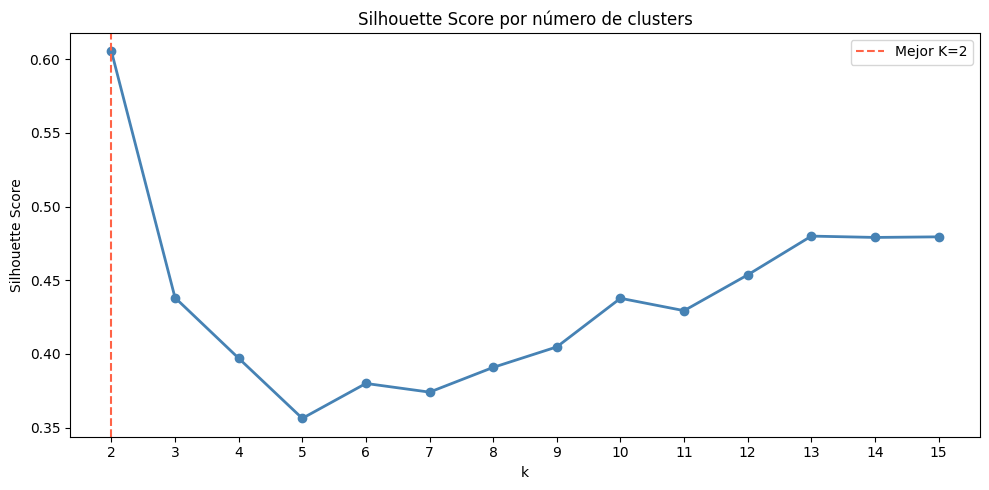

In [33]:
# === GRÁFICO DE SILHOUETTE ===
plt.figure(figsize=(10, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()),
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='tomato', linestyle='--', linewidth=1.5, label=f'Mejor K={best_k}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.xticks(range(2, 16))
plt.legend()
plt.tight_layout()
plt.show()

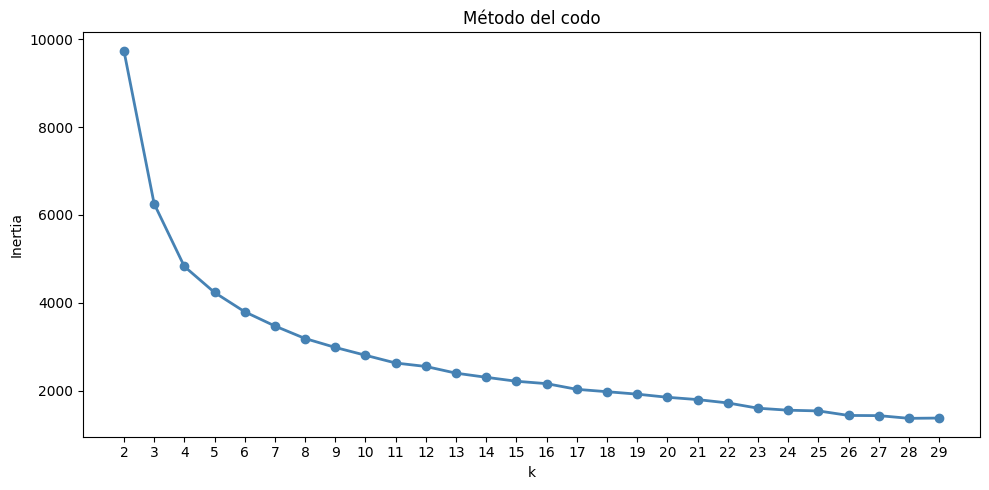

In [32]:
# método del codo
inercias = []  # creo una lista para almacenar la inercia de cada modelo

for k in range(2, 30):  # itero sobre los valores de k desde 2 hasta 29
    km = KMeans(n_clusters=k, random_state=11, n_init=15)  # creo el modelo con k clusters
    km.fit(farmacos_trans)  # ajusto el modelo a los datos transformados
    inercias.append(km.inertia_)  # almaceno la inercia del modelo

plt.figure(figsize=(10, 5))
plt.plot(range(2, 30), inercias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Método del codo')
plt.xticks(range(2, 30))
plt.tight_layout()
plt.show()

#### Genera el K-Means final

In [29]:
modelo_km_final = KMeans(n_clusters=best_k, random_state=11, n_init=10) # creo el modelo de KMeans final utilizando el mejor valor de K encontrado, la misma semilla y n_init=10
farmacos_def["cluster"] = modelo_km_final.fit_predict(farmacos_trans) # ajusto el modelo final a los datos transformados y asigno las etiquetas de cluster obtenidas a una nueva columna "cluster" en el dataframe original con las columnas seleccionadas

print("Distribución de clusters:") 
print(farmacos_def["cluster"].value_counts()) # imprimo la distribución de muestras en cada cluster utilizando value_counts() sobre la columna "cluster" del dataframe original con las columnas seleccionadas

Distribución de clusters:
cluster
0    2287
1     820
Name: count, dtype: int64


In [34]:
farmacos_def.head()

,rating,effectiveness,sideEffects,cluster
0,4,Highly Effective,Mild Side Effects,1
1,1,Highly Effective,Severe Side Effects,1
2,10,Highly Effective,No Side Effects,0
3,3,Marginally Effective,Mild Side Effects,1
4,2,Marginally Effective,Severe Side Effects,1


#### Comprueba los resultados

In [30]:
# agrupo por cluster y calculo la media de las columnas numéricas para cada cluster
farmacos_def.groupby("cluster").mean(numeric_only=True)

,rating
cluster,
0,8.56843
1,2.64878


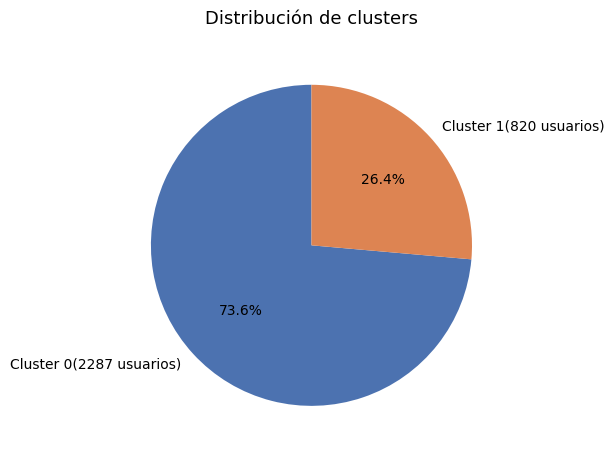

In [31]:
conteo = farmacos_def["cluster"].value_counts().sort_index() # cuento el número de muestras en cada cluster utilizando value_counts() sobre la columna "cluster" y ordeno por índice para que los clusters estén en orden numérico
etiquetas = [f"Cluster {i}({v} usuarios)" for i, v in conteo.items()] # creo una lista de etiquetas para cada cluster con su número de usuarios utilizando una comprensión de listas que itera sobre los items del conteo de clusters

# gráfico de tarta para visualizar la distribución de clusters
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(conteo, labels=etiquetas, autopct="%1.1f%%", 
       startangle=90, colors=["#4C72B0", "#DD8452"])
ax.set_title(f"Distribución de clusters", fontsize=13, pad=15)
plt.tight_layout();